[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/RO/capitol9_notebook_seminar.ipynb)

# Modelarea piețelor financiare — Seminarul 9: Volatilitate realizată

*Notebook de seminar. Daniel Traian Pele, Antoaneta Amza, Academia de Studii Economice din București.*

- Problemele **[Rezolvat]** conțin rezolvarea completă; problemele **[Propus]** le rezolvați voi.
- Partea A: pe hârtie (A1–A8); Partea B: calcul și inferență (B1–B8); Partea C: întrebare deschisă.

> Rezolvările se discută la seminar.

In [ ]:
# Pe Colab, instalați întâi arch: !pip install arch
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Stil și funcții ajutătoare

In [ ]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand (gri doar pentru linii de referinta si benzi)
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Teal     = '#17A2B8'
Gray     = '#7F7F7F'
LightGray = '#DADADA'
MODEL_COL = {'logHAR': IDAred, 'HAR': Orange, 'GARCH-t': MainBlue, 'EWMA': Purple, 'RW': Forest}

HERE = '.'
SEED = 42
OOS_SPY = '2022-01-03'
OOS_BTC = '2025-03-01'
B_BOOT = 2000
C_START = '2025-03-01'


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=0.0):
    """O singura legenda pentru o figura cu mai multe panouri, sub figura."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            h, l = ax.get_legend_handles_labels()
            for hh, ll in zip(h, l):
                if ll not in labels:
                    handles.append(hh)
                    labels.append(ll)
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def jsonable(x):
    if isinstance(x, dict):
        return {str(k): jsonable(v) for k, v in x.items()}
    if isinstance(x, (list, tuple, np.ndarray)):
        return [jsonable(v) for v in x]
    if isinstance(x, (np.floating, np.integer)):
        return x.item()
    if isinstance(x, (np.bool_,)):
        return bool(x)
    if isinstance(x, pd.Timestamp):
        return str(x.date())
    return x


def ann(v, ppy):
    """Volatilitatea anualizata (%) dintr-o varianta zilnica (%^2)."""
    return np.sqrt(ppy * v)


import tempfile
HERE = tempfile.gettempdir()   # tabelele intermediare sunt scrise intr-un folder temporar


def save_fig(name):
    """Afiseaza figura."""
    plt.show()
    plt.close()

## Măsuri realizate, HAR și evaluarea prognozelor

- `rv`, `bv`, `tq`, `rq`, `rv_ci`, `jump_test`: varianța realizată, variația bipower, cvarticități, interval de încredere, testul de salturi.
- `sparse_rv`, `subsampled_rv`, `signature`, `tsrv`, `realized_kernel`, `noise_var`: eșantionare și zgomot de microstructură.
- `har_design`, `ols_nw`, `har_fit`, `har_expanding`, `har_weights`: HAR-RV cu erori Newey–West și prognoze în afara eșantionului.
- `garch_forecasts`, `ewma_forecasts`, `qlike`, `mse`, `dm_test`, `mz_test`, `block_bootstrap`, `roughness`.

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.special import gamma as G

MU1 = np.sqrt(2 / np.pi)                              # E|Z|, Z ~ N(0,1)
MU43 = 2 ** (2 / 3) * G(7 / 6) / G(1 / 2)             # E|Z|^{4/3}


# =============================================================================
# ESTIMATORI REALIZATI (o valoare pe zi)
# =============================================================================
def rv(R):
    """Varianta realizata: suma patratelor randamentelor intraday."""
    return (R ** 2).sum(axis=1, min_count=1)


def nret(R):
    """Numarul de randamente intraday al fiecarei zile."""
    return R.notna().sum(axis=1)


def bv(R):
    """Variatia bipower (Barndorff-Nielsen si Shephard): robusta la salturi."""
    a = R.abs().values
    M = nret(R).values
    s = np.nansum(a[:, 1:] * a[:, :-1], axis=1)
    return pd.Series(MU1 ** -2 * M / (M - 1) * s, index=R.index)


def tq(R):
    """Tripower quarticity: estimeaza cvarticitatea integrata, robusta la salturi."""
    a = R.abs().values ** (4 / 3)
    M = nret(R).values
    s = np.nansum(a[:, 2:] * a[:, 1:-1] * a[:, :-2], axis=1)
    return pd.Series(M * MU43 ** -3 * M / (M - 2) * s, index=R.index)


def rq(R):
    """Cvarticitatea realizata (M/3) * suma r^4."""
    return nret(R) / 3 * (R ** 4).sum(axis=1)


def rv_ci(R, level=0.95):
    """Interval de incredere asimptotic pentru varianta integrata, construit pe scara log."""
    v = rv(R)
    se_log = np.sqrt(2 / 3 * (R ** 4).sum(axis=1)) / v
    z = stats.norm.ppf(0.5 + level / 2)
    return v * np.exp(-z * se_log), v * np.exp(z * se_log)


def jump_test(R, alpha=0.001):
    """Testul de salturi cu raportul (RV - BV)/RV (Huang si Tauchen); salt semnificativ daca z > z_{1-alpha}."""
    v, b, t = rv(R), bv(R), tq(R)
    M = nret(R)
    theta = MU1 ** -4 + 2 * MU1 ** -2 - 5
    z = ((v - b) / v) / np.sqrt(theta / M * np.maximum(1, t / b ** 2))
    jump = z > stats.norm.ppf(1 - alpha)
    J = np.where(jump, np.maximum(v - b, 0), 0.0)
    return pd.DataFrame({'rv': v, 'bv': b, 'tq': t, 'z': z, 'jump': jump, 'J': J, 'C': v - J})


# =============================================================================
# ZGOMOT DE MICROSTRUCTURA
# =============================================================================
def sparse_points(P, k, offset=0):
    """Preturile la fiecare al k-lea punct al grilei, pornind de la offset; deschiderea si inchiderea se pastreaza."""
    out = {}
    last = P.notna().values.cumsum(axis=1).argmax(axis=1)
    cols = np.arange(P.shape[1])
    X = P.values
    for i, day in enumerate(P.index):
        idx = cols[(cols >= offset) & ((cols - offset) % k == 0) & (cols <= last[i])]
        idx = np.unique(np.r_[0, idx, last[i]])
        out[day] = np.log(X[i, idx])
    return out


def sparse_rv(P, k, offset=0):
    """Varianta realizata din randamente de k x 5 minute (o singura grila)."""
    pts = sparse_points(P, k, offset)
    return pd.Series({d: np.sum((100 * np.diff(x)) ** 2) for d, x in pts.items()})


def subsampled_rv(P, k):
    """Media variantelor realizate pe cele k grile decalate (esantionare rara fara pierdere de date)."""
    return pd.concat([sparse_rv(P, k, o) for o in range(k)], axis=1).mean(axis=1)


def signature(P, ks, scale):
    """Graficul semnaturii: volatilitatea anualizata medie (%) in functie de intervalul de esantionare."""
    return pd.DataFrame({
        'sparse': [np.sqrt(scale * sparse_rv(P, k).mean()) for k in ks],
        'subsampled': [np.sqrt(scale * subsampled_rv(P, k).mean()) for k in ks]}, index=list(ks))


def tsrv(P, K=6):
    """Two-scale realised variance (Zhang, Mykland si Ait-Sahalia): media pe K grile minus corectia de zgomot."""
    R = 100 * np.log(P).diff(axis=1).iloc[:, 1:]
    n = nret(R)
    nbar = (n - K + 1) / K
    return subsampled_rv(P, K) - nbar / n * rv(R)


def noise_var(R):
    """Varianta zgomotului: omega^2 = -cov(r_i, r_{i-1}) si limita superioara RV/(2n), medii pe zile."""
    X = R.values
    cov1 = np.nanmean(X[:, 1:] * X[:, :-1])
    return {'omega2_cov': max(-cov1, 0.0), 'omega2_rv': float((rv(R) / (2 * nret(R))).mean()),
            'rho1': float(pd.Series(X[:, 1:].ravel()).corr(pd.Series(X[:, :-1].ravel())))}


def parzen(x):
    x = np.abs(x)
    return np.where(x <= 0.5, 1 - 6 * x ** 2 + 6 * x ** 3, np.where(x <= 1, 2 * (1 - x) ** 3, 0.0))


def realized_kernel(R, P, c=3.5134):
    """Nucleu realizat Parzen (Barndorff-Nielsen, Hansen, Lunde si Shephard); latimea H dupa regula lor."""
    out, Hs = {}, {}
    iv20 = sparse_rv(P, 4)                                  # varianta pe grila de 20 de minute, pentru xi
    for i, day in enumerate(R.index):
        r = R.iloc[i].dropna().values
        n = len(r)
        om2 = np.sum(r ** 2) / (2 * n)
        xi2 = om2 / max(iv20[day], 1e-12)
        H = max(1, int(np.ceil(c * xi2 ** 0.4 * n ** 0.6)))
        g = [np.sum(r[h:] * r[:n - h]) for h in range(H + 1)]
        out[day] = g[0] + 2 * sum(parzen(h / (H + 1)) * g[h] for h in range(1, H + 1))
        Hs[day] = H
    return pd.Series(out), pd.Series(Hs)


# =============================================================================
# HAR-RV
# =============================================================================
def har_design(v, calendar=False):
    """Regresori HAR: componenta zilnica, saptamanala, lunara (5 si 22 de zile de tranzactionare;
    pentru cripto, pe calendar: 7 si 30 de zile, cu cel putin 5, respectiv 20 de observatii)."""
    if calendar:
        full = v.asfreq('D')
        d = full.shift(1)
        w = full.rolling(7, min_periods=5).mean().shift(1)
        m = full.rolling(30, min_periods=20).mean().shift(1)
        X = pd.DataFrame({'d': d, 'w': w, 'm': m}).reindex(v.index)
    else:
        X = pd.DataFrame({'d': v.shift(1), 'w': v.rolling(5).mean().shift(1), 'm': v.rolling(22).mean().shift(1)})
    return X


def nw_lags(T):
    return int(np.floor(4 * (T / 100) ** (2 / 9)))


def ols_nw(y, X, lags=None):
    """MCO cu termen liber si erori standard Newey-West (HAC)."""
    Xc = np.column_stack([np.ones(len(X)), np.asarray(X, float)])
    y = np.asarray(y, float)
    T, k = Xc.shape
    XtX_inv = np.linalg.inv(Xc.T @ Xc)
    b = XtX_inv @ Xc.T @ y
    e = y - Xc @ b
    L = nw_lags(T) if lags is None else lags
    u = Xc * e[:, None]
    S = u.T @ u
    for l in range(1, L + 1):
        w = 1 - l / (L + 1)
        g = u[l:].T @ u[:-l]
        S += w * (g + g.T)
    V = XtX_inv @ S @ XtX_inv
    r2 = 1 - e @ e / np.sum((y - y.mean()) ** 2)
    return {'b': b, 'se': np.sqrt(np.diag(V)), 'V': V, 'r2': r2, 'resid': e, 'T': T, 'lags': L}


def har_fit(v, calendar=False, log=False, jumps=None):
    """HAR-RV pe esantionul complet; log=True: HAR pe log RV; jumps: componenta de salt ca regresor suplimentar."""
    X = har_design(np.log(v) if log else v, calendar)
    if jumps is not None:
        X['J'] = jumps.shift(1).reindex(X.index) if not calendar else jumps.asfreq('D').shift(1).reindex(X.index)
    y = np.log(v) if log else v
    ok = X.notna().all(axis=1)
    return ols_nw(y[ok], X[ok]), X, ok


def har_expanding(v, start, calendar=False, log=False, min_obs=100):
    """Prognoze HAR pentru ziua t, estimate zilnic pe toate observatiile anterioare lui t (fereastra extinsa)."""
    y = np.log(v) if log else v
    X = har_design(y, calendar)
    ok = X.notna().all(axis=1)
    Xv, yv = X.values, y.values
    Xc = np.column_stack([np.ones(len(X)), Xv])
    out = {}
    for t in np.where((v.index >= pd.Timestamp(start)) & ok.values)[0]:
        tr = np.where(ok.values[:t])[0]
        if len(tr) < min_obs:
            continue
        b, *_ = np.linalg.lstsq(Xc[tr], yv[tr], rcond=None)
        f = Xc[t] @ b
        if log:
            s2 = np.var(yv[tr] - Xc[tr] @ b)
            f = np.exp(f + s2 / 2)
        out[v.index[t]] = f
    return pd.Series(out)


def har_weights(b, n=30):
    """Ponderile implicite ale HAR pe fiecare intarziere 1..n (HAR = AR(22) restrictionat)."""
    w = np.zeros(n)
    w[0] += b[1]
    w[:5] += b[2] / 5
    w[:22] += b[3] / 22
    return w


# =============================================================================
# REPERE: GARCH SI EWMA PE RANDAMENTE ZILNICE
# =============================================================================
def garch_forecasts(r, dates, refit=21, dist='t'):
    """Varianta prognozata pentru fiecare zi din dates cu GARCH(1,1), reestimat la fiecare `refit` zile
    pe toate datele anterioare; intre reestimari parametrii raman fixi, iar varianta se actualizeaza zilnic."""
    from arch import arch_model
    dates = pd.DatetimeIndex(dates)
    pos = r.index.get_indexer(dates)
    out = pd.Series(np.nan, index=dates)
    for i0 in range(0, len(dates), refit):
        blk = dates[i0:i0 + refit]
        p0 = pos[i0]
        fit = arch_model(r.iloc[:p0], mean='Constant', vol='GARCH', p=1, q=1, dist=dist).fit(disp='off')
        fixed = arch_model(r.iloc[:pos[min(i0 + refit, len(dates)) - 1] + 1], mean='Constant', vol='GARCH', p=1, q=1,
                           dist=dist).fix(fit.params)
        out[blk] = (fixed.conditional_volatility ** 2).reindex(blk).values
    return out


def ewma_forecasts(r, lam=0.94, burn=250):
    """RiskMetrics: sigma^2_t = lambda sigma^2_{t-1} + (1 - lambda) r^2_{t-1}."""
    x = r.values
    s = np.empty(len(x))
    s[0] = np.var(x[:burn])
    for t in range(1, len(x)):
        s[t] = lam * s[t - 1] + (1 - lam) * x[t - 1] ** 2
    return pd.Series(s, index=r.index)


# =============================================================================
# EVALUAREA PROGNOZELOR
# =============================================================================
def qlike(v, f):
    """QLIKE: v/f - log(v/f) - 1 (robusta la zgomotul proxy-ului, Patton 2011)."""
    return v / f - np.log(v / f) - 1


def mse(v, f):
    return (v - f) ** 2


def dm_test(l1, l2):
    """Diebold-Mariano: d = l1 - l2; t = media(d)/se_NW; d < 0 => modelul 1 are pierdere mai mica."""
    d = (l1 - l2).dropna().values
    res = ols_nw(d, np.empty((len(d), 0)))
    t = res['b'][0] / res['se'][0]
    return {'mean_diff': float(d.mean()), 't': float(t), 'p': float(2 * stats.norm.sf(abs(t))), 'T': len(d)}


def mz_test(v, f):
    """Regresia Mincer-Zarnowitz v = a + b f + e; test Wald comun (a, b) = (0, 1) cu covarianta NW."""
    res = ols_nw(v.values, f.values[:, None])
    dlt = res['b'] - np.array([0.0, 1.0])
    W = float(dlt @ np.linalg.inv(res['V']) @ dlt)
    return {'a': res['b'][0], 'b': res['b'][1], 'se_a': res['se'][0], 'se_b': res['se'][1], 'r2': res['r2'],
            'wald': W, 'p': float(stats.chi2.sf(W, 2))}


def block_bootstrap(x, stat, block=20, B=2000, seed=42):
    """Bootstrap pe blocuri mobile (Kunsch): distributia statisticii `stat` pe serii reconstruite din blocuri."""
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    n = len(x)
    nb = int(np.ceil(n / block))
    out = np.empty(B)
    for b in range(B):
        starts = rng.integers(0, n - block + 1, nb)
        idx = (starts[:, None] + np.arange(block)[None, :]).ravel()[:n]
        out[b] = stat(x[idx])
    return out


# =============================================================================
# VOLATILITATE ASPRA
# =============================================================================
def roughness(logsig, qs=(0.5, 1.0, 1.5, 2.0, 3.0), lags=range(1, 31)):
    """m(q, D) = media |log sigma_{t+D} - log sigma_t|^q ~ D^{q H}: panta zeta_q = q H pe scara log-log."""
    x = np.asarray(logsig)
    lags = np.array(list(lags))
    M = {q: np.array([np.mean(np.abs(x[l:] - x[:-l]) ** q) for l in lags]) for q in qs}
    zeta = {q: np.polyfit(np.log(lags), np.log(M[q]), 1)[0] for q in qs}
    H = np.polyfit(list(qs), [zeta[q] for q in qs], 1)[0] if len(qs) > 1 else zeta[qs[0]] / qs[0]
    return {'lags': lags, 'm': M, 'zeta': zeta, 'H': float(H)}

## Date

- SPY: bare de 5 minute din sesiunea regulată din SUA (09:30–16:00 ora New York), octombrie 2020 – septembrie 2026.
- Bitcoin: bare de 5 minute, zile UTC de 24 de ore cu cel puțin 95% din bare, septembrie 2024 – septembrie 2026.
- Închideri zilnice SPY (ajustate) și Bitcoin și indicele VIX.
- Randamente în %, varianțe zilnice în %²; varianța zilnică totală SPY = RV intraday + randamentul peste noapte la pătrat.

In [ ]:
import os
import numpy as np
import pandas as pd

REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# nume -> (simbol, coloana, eticheta, 7 zile din 7?)
DAILY = {
    'spy': ('SPY.US', 'adjusted_close', 'SPY (S&P 500 ETF)', False),
    'sp500': ('GSPC.INDX', 'close', 'S&P 500', False),
    'btc': ('BTC-USD.CC', 'close', 'Bitcoin', True),
    'vix': ('VIX.INDX', 'close', 'VIX', False),
}


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_intraday(symbol):
    """Citeste data/market/intraday/<SIMBOL>_5m.csv (ora UTC)."""
    fname = f'intraday/{symbol}_5m.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    d = pd.read_csv(src, index_col='datetime_utc', parse_dates=True).sort_index()
    return d[~d.index.duplicated(keep='last')]


def daily_close(name, start=None, end=END):
    """Pretul zilnic: fara cotatii de weekend (in afara de cripto) si fara zile cu pret neschimbat (indici)."""
    symbol, col, _, all_week = DAILY[name]
    s = read_market(symbol)[col].loc[start:end]
    s = s[s > 0].dropna()
    if not all_week:
        s = s[s.index.dayofweek < 5]
    if name in ('sp500', 'vix'):
        s = s[s.diff() != 0]
    return s.rename(name)


def daily_returns(name, start=None, end=END):
    """Randamente log zilnice, in %, pe calendarul propriu al seriei."""
    return (100 * np.log(daily_close(name, start, end)).diff().dropna()).rename(name)


def spy_intraday(end=END):
    """Preturile SPY din sesiunea regulata: matrice zi x 79 de puncte (deschiderea de 09:30 + 78 de inchideri)."""
    d = read_intraday('SPY.US')
    d.index = d.index.tz_localize('UTC').tz_convert('America/New_York')
    d = d[(d.index.second == 0) & (d.index.minute % 5 == 0)]            # fara bare din afara grilei
    mins = d.index.hour * 60 + d.index.minute
    d = d[(mins >= 9 * 60 + 30) & (mins <= 15 * 60 + 55)]               # 09:30-15:55 (fara bara-ciot de 16:00)
    d = d.loc[:end + ' 23:59']
    slot = ((d.index.hour * 60 + d.index.minute) - (9 * 60 + 30)) // 5  # 0..77
    day = pd.to_datetime(d.index.date)
    close = pd.DataFrame({'day': day, 'slot': slot, 'p': d['close'].values}).pivot(index='day', columns='slot', values='p')
    first = pd.Series(d['open'].values, index=day)[slot == 0]
    first = first[~first.index.duplicated()]
    P = pd.concat([first.rename(-1), close], axis=1).sort_index(axis=1)
    P = P[P[0].notna() & P[-1].notna()]
    P.columns = range(P.shape[1])                                        # 0 = deschiderea, 1..78 = inchiderile barelor
    last = P.notna().values.cumsum(axis=1).argmax(axis=1)                # ultima bara disponibila a zilei
    F = P.ffill(axis=1)                                                  # bare lipsa in interiorul zilei: pretul anterior
    F = F.where(np.arange(P.shape[1])[None, :] <= last[:, None])         # dupa inchiderea zilelor scurte: NaN
    return F


def btc_intraday(end=END, min_share=0.95):
    """Preturile Bitcoin pe zile UTC: matrice zi x 289 de puncte (deschiderea de 00:00 + 288 de inchideri)."""
    d = read_intraday('BTC-USD.CC')
    d = d[d['close'].notna() & (d['close'] > 0)].loc[:end + ' 23:59']
    g = d.resample('5min', label='left', closed='left').agg({'open': 'first', 'close': 'last'})
    have = g['close'].notna()
    day = pd.to_datetime(g.index.date)
    n = have.groupby(day).sum()
    keep = n[n >= min_share * 288].index
    g = g[day.isin(keep)]
    day = pd.to_datetime(g.index.date)
    slot = (g.index.hour * 60 + g.index.minute) // 5
    close = pd.DataFrame({'day': day, 'slot': slot, 'p': g['close'].values}).pivot(index='day', columns='slot', values='p')
    close = close.ffill(axis=1)                                          # goluri scurte: ultimul pret cunoscut
    op = pd.DataFrame({'day': day, 'slot': slot, 'p': g['open'].values}).pivot(index='day', columns='slot', values='p')
    first = op.bfill(axis=1)[0].fillna(close[0])
    close = close.bfill(axis=1)                                          # zi care incepe cu un gol
    P = pd.concat([first.rename(-1), close], axis=1).sort_index(axis=1)
    P.columns = range(P.shape[1])
    return P


def intraday_returns(P):
    """Randamentele log intr-o zi, in %: coloana j = intervalul (j-1, j]; NaN dupa inchiderea zilelor scurte."""
    return 100 * np.log(P).diff(axis=1).iloc[:, 1:]


def spy_overnight(P):
    """Randamentul peste noapte (%): randamentul zilnic ajustat minus randamentul deschidere-inchidere al zilei."""
    oc = 100 * np.log(P.ffill(axis=1).iloc[:, -1] / P[0])
    cc = daily_returns('spy').reindex(P.index)
    return (cc - oc).rename('overnight'), oc.rename('open_close'), cc.rename('close_close')


# ---- date folosite in toate analizele
P_SPY = spy_intraday()
R_SPY = intraday_returns(P_SPY)
ON, OC, CC = spy_overnight(P_SPY)
RV_SPY = rv(R_SPY)                       # varianta realizata intraday (%^2)
RVT_SPY = RV_SPY + ON ** 2                 # varianta zilnica totala: intraday + randamentul peste noapte la patrat
P_BTC = btc_intraday()
R_BTC = intraday_returns(P_BTC)
RV_BTC = rv(R_BTC)
D_SPY = daily_returns('spy', start='2000-01-01')
D_BTC = daily_returns('btc', start='2014-09-17')
print('SPY:', RV_SPY.index[0].date(), '->', RV_SPY.index[-1].date(), len(RV_SPY), 'days')
print('Bitcoin:', RV_BTC.index[0].date(), '->', RV_BTC.index[-1].date(), len(RV_BTC), 'days')

## Funcțiile seminarului

- Estimatorul asprimii folosit la B8 (din `generate_all_charts.py`).

In [ ]:
A1_R = np.array([0.08, -0.15, 0.03, 0.1, -0.04, 0.12])


def rough_H(logsig, qs=(0.5, 1.0, 1.5, 2.0, 3.0), lags=range(1, 31)):
    """H = panta dreptei zeta_q = q H, prin origine."""
    ro = roughness(logsig, qs, lags)
    q = np.array(qs)
    z = np.array([ro['zeta'][x] for x in qs])
    ro['H'] = float(np.sum(q * z) / np.sum(q * q))
    return ro

## Partea A — pe hârtie

### A1. Varianța realizată și variația bipower, pas cu pas [Rezolvat]

- Șase randamente de 5 minute (%): 0,08, −0,15, 0,03, 0,10, −0,04, 0,12: RV, BV, (RV − BV)/RV, RV pe 15 minute, volatilitatea anualizată.

In [6]:
def a1_rv_bv(r=A1_R):
    """RV, BV si ponderea variatiei nediscutate de BV pentru sase randamente de 5 minute (%)."""
    M_ = len(r)
    v = np.sum(r ** 2)
    s = np.sum(np.abs(r[1:]) * np.abs(r[:-1]))
    b = (np.pi / 2) * M_ / (M_ - 1) * s
    sparse = np.sum(np.array([r[:3].sum(), r[3:].sum()]) ** 2)
    return {'rv': v, 's': s, 'bv': b, 'ratio': (v - b) / v, 'sparse15': sparse,
            'vol_ann': np.sqrt(252 * v * 78 / M_), 'sq': list(r ** 2), 'prod': list(np.abs(r[1:]) * np.abs(r[:-1]))}


a1_rv_bv()

{'rv': np.float64(0.0558),
 's': np.float64(0.0283),
 'bv': np.float64(0.053344243257954685),
 'ratio': np.float64(0.04400997745600927),
 'sparse15': np.float64(0.033999999999999996),
 'vol_ann': np.float64(13.520384609914025),
 'sq': [np.float64(0.0064),
  np.float64(0.0225),
  np.float64(0.0009),
  np.float64(0.010000000000000002),
  np.float64(0.0016),
  np.float64(0.0144)],
 'prod': [np.float64(0.012),
  np.float64(0.0045),
  np.float64(0.003),
  np.float64(0.004),
  np.float64(0.0048)]}

### A2. Un salt în șase randamente [Propus]

- Aceleași randamente, ultimul este −0,90%: RV, BV, partea de salt, statistica raportului cu M = 6. Model: A1.

In [ ]:
# Codul vostru aici


### A3. Deplasarea din zgomot și eșantionarea optimă [Rezolvat]

- IV = 1 %², ω = 0,01%: E[RV] la 5 minute, 1 minut, 1 secundă; n* optim.

In [8]:
def a3_noise(iv=1.0, omega=0.01):
    """Bias-ul zgomotului: E[RV] = IV + 2 n omega^2; frecventa optima n* = (IQ / (4 omega^4))^(1/3) cu IQ = IV^2."""
    rows = {n: {'bias': 2 * n * omega ** 2, 'erv': iv + 2 * n * omega ** 2} for n in (78, 390, 23400)}
    nstar = (iv ** 2 / (4 * omega ** 4)) ** (1 / 3)
    return {'rows': rows, 'nstar': nstar, 'secs': 23400 / nstar, 'omega2': omega ** 2}


a3_noise()

{'rows': {78: {'bias': 0.015600000000000001, 'erv': 1.0156},
  390: {'bias': 0.078, 'erv': 1.078},
  23400: {'bias': 4.680000000000001, 'erv': 5.680000000000001}},
 'nstar': 292.4017738212865,
 'secs': 80.02687430446944,
 'omega2': 0.0001}

### A4. O acțiune mai puțin lichidă [Propus]

- ω = 0,03%: deplasarea, n* optim; RV pe două scări din RV_all = 1,70 și RV_avg = 1,10. Model: A3.

In [ ]:
# Codul vostru aici


### A5. O prognoză log-HAR [Rezolvat]

- β = (−0,08, 0,36, 0,34, 0,17); RV azi 2,0, media log săptămânală ln 1,2, lunară ln 0,9: prognoza, ponderile pe întârzieri, persistența.

In [10]:
def a5_har(b=(-0.08, 0.36, 0.34, 0.17), d=np.log(2.0), w=np.log(1.2), m=np.log(0.9)):
    """Prognoza log-HAR pentru maine; ponderi implicite pe intarzieri; persistenta."""
    lf = b[0] + b[1] * d + b[2] * w + b[3] * m
    return {'lf': lf, 'f': np.exp(lf), 'w1': b[1] + b[2] / 5 + b[3] / 22, 'w2': b[2] / 5 + b[3] / 22, 'w6': b[3] / 22,
            'pers': b[1] + b[2] + b[3], 'mean': np.exp(b[0] / (1 - sum(b[1:]))), 'd': d, 'w': w, 'm': m}


a5_har()

{'lf': np.float64(0.2136110266496944),
 'f': np.float64(1.2381409572794742),
 'w1': 0.43572727272727274,
 'w2': 0.07572727272727273,
 'w6': 0.007727272727272728,
 'pers': 0.87,
 'mean': np.float64(0.5404329964865341),
 'd': np.float64(0.6931471805599453),
 'w': np.float64(0.1823215567939546),
 'm': np.float64(-0.10536051565782628)}

### A6. QLIKE și MSE pas cu pas [Rezolvat]

- RV = 0,8, 1,5, 0,6; prognozele A = 1, 1, 1 și B = 0,6, 1,6, 0,4.

In [11]:
def a6_losses():
    """QLIKE si MSE pentru doua prognoze pe trei zile."""
    v = np.array([0.8, 1.5, 0.6])
    fa = np.array([1.0, 1.0, 1.0])
    fb = np.array([0.6, 1.6, 0.4])
    out = {}
    for k, f in [('A', fa), ('B', fb)]:
        q = v / f - np.log(v / f) - 1
        e = (v - f) ** 2
        out[k] = {'q': list(q), 'qm': q.mean(), 'e': list(e), 'em': e.mean()}
    # prognoza de 2 ori prea mica vs de 2 ori prea mare (v = 1)
    out['under'] = 1 / 0.5 - np.log(1 / 0.5) - 1
    out['over'] = 1 / 2.0 - np.log(1 / 2.0) - 1
    out['under_mse'] = (1 - 0.5) ** 2
    out['over_mse'] = (1 - 2.0) ** 2
    return out


a6_losses()

{'A': {'q': [np.float64(0.023143551314209754),
   np.float64(0.09453489189183562),
   np.float64(0.11082562376599059)],
  'qm': np.float64(0.07616802232401199),
  'e': [np.float64(0.03999999999999998),
   np.float64(0.25),
   np.float64(0.16000000000000003)],
  'em': np.float64(0.15)},
 'B': {'q': [np.float64(0.04565126088155247),
   np.float64(0.002038521137571081),
   np.float64(0.09453489189183562)],
  'qm': np.float64(0.047408224636986386),
  'e': [np.float64(0.04000000000000003),
   np.float64(0.010000000000000018),
   np.float64(0.03999999999999998)],
  'em': np.float64(0.03000000000000001)},
 'under': np.float64(0.3068528194400546),
 'over': np.float64(0.1931471805599454),
 'under_mse': 0.25,
 'over_mse': 1.0}

### A7. O prognoză log-HAR pe două zile [Propus]

- RV în ultimele cinci zile 2,0, 1,6, 1,3, 1,1, 1,0; media log lunară ln 0,9. Model: A5.

In [ ]:
# Codul vostru aici


### A8. Diebold–Mariano și Mincer–Zarnowitz pas cu pas [Propus]

- Diferența medie QLIKE −0,0327, eroarea standard HAC 0,0142; MZ pentru GARCH a = 0,24 (0,23), b = 0,70 (0,24). Model: A6.

In [ ]:
# Codul vostru aici


## Partea B — calcul și inferență

### B1. Salturi în SPY [Rezolvat]

- Statistica raportului pentru fiecare zi; respingeri la 5%, 1%, 0,1% față de numărul așteptat; ora celui mai mare randament de 5 minute în zilele cu salt.
- Interpretare: indică orele salturilor știri programate?

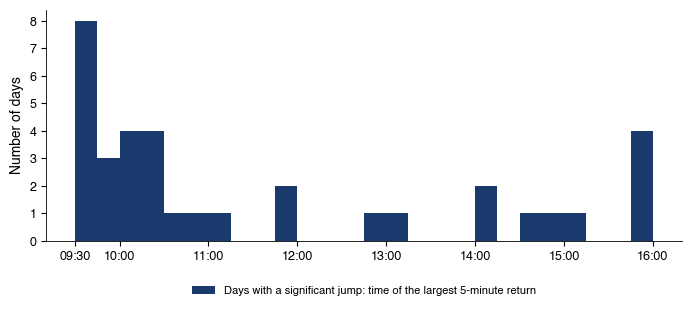

{'N': 1489,
 'n5': 235,
 'share5': 0.15782404298186703,
 'exp5': 74.45,
 'n1': 110,
 'share1': 0.07387508394895903,
 'exp1': 14.89,
 'n0_1': 35,
 'share0_1': 0.02350570852921424,
 'exp0_1': 1.489,
 'at10': 0.05714285714285714,
 'at14': 0.05714285714285714,
 'n_jump': 35,
 'top': [{'date': '2021-08-27',
   'z': 5.218990969338793,
   'jshare': 0.49309151100370663,
   'time': '10:05'},
  {'date': '2022-01-03',
   'z': 5.213766014936756,
   'jshare': 0.46238027303735096,
   'time': '09:50'},
  {'date': '2025-08-25',
   'z': 4.771238432226234,
   'jshare': 0.4215899387016839,
   'time': '16:00'}],
 'jshare': 0.028357370498370525,
 'z_mean': 0.49603864695663646,
 'z_sd': 1.1431418238917002}

In [14]:
def b1_spy_jumps():
    """Testul de salturi pe SPY la trei niveluri; ora celui mai mare randament in zilele cu salt."""
    j = jump_test(R_SPY)
    out = {'N': int(len(j))}
    for a, tag in [(0.05, '5'), (0.01, '1'), (0.001, '0_1')]:
        k = int((j['z'] > stats.norm.ppf(1 - a)).sum())
        out[f'n{tag}'] = k
        out[f'share{tag}'] = k / len(j)
        out[f'exp{tag}'] = a * len(j)
    jd = j[j['jump']].index
    slot = R_SPY.loc[jd].abs().idxmax(axis=1).astype(int)          # coloana 1..78 = intervalul care se termina la 09:30 + 5*col
    end = pd.Timestamp('2000-01-01 09:30') + pd.to_timedelta(5 * slot.values, unit='min')
    hours = pd.Series([t.strftime('%H:%M') for t in end], index=jd)
    at10 = float(np.mean([(t.hour == 10 and t.minute <= 5) for t in end]))
    at14 = float(np.mean([(t.hour == 14 and t.minute <= 5) or (t.hour == 14 and t.minute == 0) for t in end]))
    fig, ax = plt.subplots(figsize=(8.2, 3.0))
    mins = np.array([(t.hour - 9) * 60 + t.minute - 30 for t in end])
    ax.hist(mins, bins=np.arange(0, 391, 15), color=MainBlue, label='Days with a significant jump: time of the largest 5-minute return')
    ax.set_xticks([0, 30, 90, 150, 210, 270, 330, 390])
    ax.set_xticklabels(['09:30', '10:00', '11:00', '12:00', '13:00', '14:00', '15:00', '16:00'])
    ax.set_ylabel('Number of days')
    legend_outside_bottom(ax, ncol=1, y=-0.15)
    save_fig('ch9_sem_jump_times')
    top = j.sort_values('z', ascending=False).head(3)
    out.update({'at10': at10, 'at14': at14, 'n_jump': int(len(jd)),
                'top': [{'date': str(d.date()), 'z': float(r['z']), 'jshare': float(r['J'] / r['rv']),
                         'time': hours[d]} for d, r in top.iterrows()],
                'jshare': float(j['J'].sum() / j['rv'].sum()), 'z_mean': float(j['z'].mean()), 'z_sd': float(j['z'].std())})
    return out


b1_spy_jumps()

### B2. Salturi în Bitcoin [Propus]

- Ponderea zilelor cu salt (test binomial), weekend vs zile lucrătoare, ponderea salturilor în variație. Model: B1.
- Interpretare: ce face o zi liniștită de weekend „cu salturi”?

In [ ]:
# Codul vostru aici


### B3. Ce frecvență de eșantionare? [Rezolvat]

- RV la 5, 15, 30, 65 de minute; raportul față de RV pe 5 minute cu CI prin bootstrap pe blocuri mobile; corelația predictivă.
- Interpretare: ce frecvență dă măsurarea cea mai utilă?

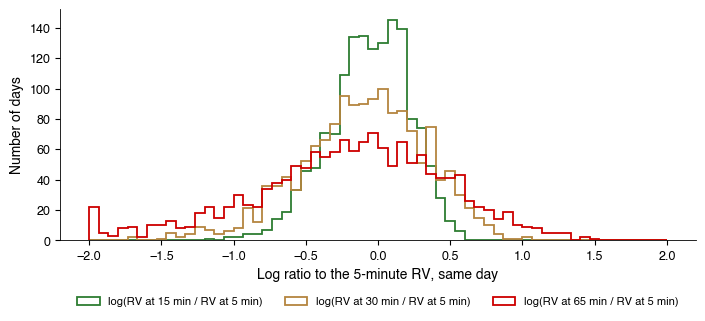

,5,15,30,65
vol,12.929,12.877,12.755,12.757
vol_sub,12.929,12.787,12.769,12.876
ratio,1.000,0.992,0.973,0.974
lo,1.000,0.954,0.933,0.913
hi,1.000,1.035,1.015,1.037
corr_next,0.727,0.709,0.701,0.643
sd_rel,0.000,0.279,0.430,0.681
corr_next_sub,0.727,0.722,0.716,0.701


In [16]:
def b3_frequency():
    """SPY: RV la 5, 15, 30 si 65 de minute; bootstrap pe blocuri pentru raportul mediilor; putere predictiva."""
    base = RV_SPY
    out = {}
    fig, ax = plt.subplots(figsize=(8.2, 3.0))
    for k, col in [(1, MainBlue), (3, Forest), (6, Amber), (13, IDAred)]:
        v = sparse_rv(P_SPY, k)
        vs = subsampled_rv(P_SPY, k)
        ratio = v.mean() / base.mean()
        boot = block_bootstrap(np.c_[v.values, base.values], lambda x: x[:, 0].mean() / x[:, 1].mean(), 20, B_BOOT, SEED)
        lv = np.log(v)
        nxt = np.log(base).shift(-1)
        c = pd.concat([lv, nxt], axis=1).dropna().corr().iloc[0, 1]
        rel = np.log(v / base)
        out[str(5 * k)] = {'vol': float(ann(v.mean(), 252)), 'vol_sub': float(ann(vs.mean(), 252)), 'ratio': float(ratio),
                           'lo': float(np.percentile(boot, 2.5)), 'hi': float(np.percentile(boot, 97.5)),
                           'corr_next': float(c), 'sd_rel': float(rel.std()),
                           'corr_next_sub': float(pd.concat([np.log(vs), nxt], axis=1).dropna().corr().iloc[0, 1])}
        if k > 1:
            ax.hist(rel.clip(-2, 2), bins=np.linspace(-2, 2, 61), histtype='step', color=col, lw=1.3,
                    label=f'log(RV at {5 * k} min / RV at 5 min)')
    ax.set_xlabel('Log ratio to the 5-minute RV, same day')
    ax.set_ylabel('Number of days')
    legend_outside_bottom(ax, ncol=3, y=-0.2)
    save_fig('ch9_sem_frequency')
    return out


pd.DataFrame(b3_frequency()).round(3)

### B4. Randamente standardizate cu volatilitatea realizată [Propus]

- Aplatizarea lui r/sd(r) și r/√RV cu CI bootstrap pe blocuri; Jarque–Bera; ponderea |z| > 3. Model: B3.
- Interpretare: de unde provin cozile grele?

In [ ]:
# Codul vostru aici


### B5. log-HAR pentru SPY cu inferență robustă [Rezolvat]

- Erori standard OLS și Newey–West, testul Wald β_w = β_m, Ljung–Box pe reziduuri, comparație cu AR(1).
- Interpretare: a surprins HAR memoria lungă?

In [18]:
def b5_har_insample():
    """log-HAR pe SPY (varianta totala), MCO cu erori obisnuite si Newey-West; Wald: beta_w = beta_m; Ljung-Box pe reziduuri."""
    res, X, ok = har_fit(RVT_SPY, log=True)
    y = np.log(RVT_SPY)[ok]
    Xc = np.column_stack([np.ones(ok.sum()), X[ok].values])
    e = res['resid']
    s2 = e @ e / (len(e) - 4)
    se_ols = np.sqrt(np.diag(s2 * np.linalg.inv(Xc.T @ Xc)))
    R = np.array([0, 0, 1, -1.0])
    wald = float((R @ res['b']) ** 2 / (R @ res['V'] @ R))
    from statsmodels.stats.diagnostic import acorr_ljungbox
    lb = acorr_ljungbox(e, lags=[10, 22])
    lb2 = acorr_ljungbox(y.values - y.mean(), lags=[10, 22])
    ar1 = ols_nw(y.values[1:], y.values[:-1, None])
    return {'b': res['b'], 'se_nw': res['se'], 'se_ols': se_ols, 'r2': res['r2'], 'T': res['T'], 'lags': res['lags'],
            'wald_wm': wald, 'p_wm': float(stats.chi2.sf(wald, 1)), 'lb10': float(lb['lb_stat'].iloc[0]), 'lb10_p': float(lb['lb_pvalue'].iloc[0]),
            'lb22': float(lb['lb_stat'].iloc[1]), 'lb22_p': float(lb['lb_pvalue'].iloc[1]), 'lby22': float(lb2['lb_stat'].iloc[1]),
            'pers': float(sum(res['b'][1:])), 'ar1_b': float(ar1['b'][1]), 'ar1_r2': float(ar1['r2']),
            't_nw': list(res['b'] / res['se']), 'ratio_se': list(res['se'] / se_ols)}


b5_har_insample()

{'b': array([-0.07874716,  0.36202234,  0.33691474,  0.16739331]),
 'se_nw': array([0.02658344, 0.03705921, 0.04823207, 0.04395403]),
 'se_ols': array([0.0249223 , 0.03058534, 0.04872425, 0.04560402]),
 'r2': np.float64(0.47030868749339905),
 'T': 1467,
 'lags': 7,
 'wald_wm': 4.171694503127457,
 'p_wm': 0.041104670254420696,
 'lb10': 9.27410603600851,
 'lb10_p': 0.5063025951157142,
 'lb22': 17.50358155328806,
 'lb22_p': 0.7349818195538907,
 'lby22': 4640.86559522571,
 'pers': 0.8663303874336665,
 'ar1_b': 0.6433879429051517,
 'ar1_r2': 0.41318391798209875,
 't_nw': [np.float64(-2.962263498362372),
  np.float64(9.768755668221962),
  np.float64(6.9852848703937545),
  np.float64(3.8083718788554517)],
 'ratio_se': [np.float64(1.0666529666153475),
  np.float64(1.2116658323098388),
  np.float64(0.9898987223521569),
  np.float64(0.9638192492801249)]}

### B6. Prognoza săptămânii următoare [Propus]

- log-HAR direct pentru suma pe 5 zile vs GARCH(1,1)-t cu formula pe h pași; QLIKE, MSE, DM, MZ. Model: B5, A6, A8.
- Interpretare: se păstrează avantajul log-HAR la un orizont săptămânal?

In [ ]:
# Codul vostru aici


### B7. Ajută salturile? Modelul HAR-CJ [Propus]

- Componentele continuă și de salt ca regresori; comparație în eșantion și în afara eșantionului cu log-HAR. Model: B5, B1.
- Interpretare: de ce un coeficient semnificativ poate să nu aducă niciun câștig de prognoză?

In [ ]:
# Codul vostru aici


### B8. Cât de aspră este volatilitatea? [Propus]

- H pentru patru măsuri cu CI bootstrap pe blocuri; mișcare browniană simulată cu și fără zgomot. Model: B3.
- Interpretare: ce efect are eroarea de măsurare asupra estimării lui H?

In [ ]:
# Codul vostru aici


## Partea C — este volatilitatea Bitcoin mai previzibilă decât cea a S&P 500? [Propus]

- Aceeași fereastră, martie 2025 – septembrie 2026: log-HAR, GARCH(1,1)-t, RV de ieri pentru SPY și Bitcoin.
- R² al log RV pe prognoza log, câștigurile QLIKE, CI bootstrap pe blocuri pentru diferența de R²; o variabilă de weekend pentru Bitcoin.

In [ ]:
# Codul vostru aici
